# AI Real Estate Agent - Data Exploration & ML Pipeline

## Overview
This notebook processes the Ames Housing dataset to build a predictive pricing model. To optimize for our LLM Prompt Chain, we have reduced the 80+ features down to 10 highly impactful features. 

### Step 1: Initialization, Data Loading, and Splitting
**Objective:** Set up the environment, load the dataset, filter our selected features, and immediately perform a 3-way split (Train/Validation/Test).

**Why split first?** To absolutely prevent **data leakage**. Any imputation (like filling missing values in `LotFrontage`) or encoding must be learned *only* from the training set and then applied to the validation and test sets.

**Directory Management:**
We will programmatically ensure that our `../data/` and `../graphs/` directories exist relative to this notebook so artifacts are saved correctly.

In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# 1. Setup Directories
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
data_dir = os.path.join(base_dir, 'data')
graph_dir = os.path.join(base_dir, 'graphs')

os.makedirs(data_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)
print(f"Directories verified:\n- Data: {data_dir}\n- Graphs: {graph_dir}")

# 2. Fetch Dataset (Ames Housing)
print("Fetching Ames Housing dataset...")
ames = fetch_openml(data_id=42165, as_frame=True, parser='auto')
df = ames.frame

# 3. Filter to our 10 chosen features + Target
selected_columns = [
    'Neighborhood', 'HouseStyle', 'GarageType', 'OverallQual', 
    'ExterQual', 'BsmtQual', 'GrLivArea', 'LotFrontage', 
    'YearBuilt', 'FullBath', 'SalePrice'
]

# Ensure we only keep our subset and drop rows where the target itself is missing
df = df[selected_columns].dropna(subset=['SalePrice']).copy()
print(f"Dataset filtered. Shape: {df.shape}")

# 4. Perform the 3-Way Split (60% Train, 20% Validation, 20% Test)
# First, split off 20% for the final Test set
df_temp, df_test = train_test_split(df, test_size=0.20, random_state=42)

# Next, split the remaining 80% into Train (75% of 80 = 60%) and Validation (25% of 80 = 20%)
df_train, df_val = train_test_split(df_temp, test_size=0.25, random_state=42)

print("\nSplit Complete:")
print(f"Train size:      {df_train.shape[0]} rows")
print(f"Validation size: {df_val.shape[0]} rows")
print(f"Test size:       {df_test.shape[0]} rows")

# Save the raw splits to the data folder for record keeping
df_train.to_csv(os.path.join(data_dir, 'train_raw.csv'), index=False)
df_val.to_csv(os.path.join(data_dir, 'val_raw.csv'), index=False)
df_test.to_csv(os.path.join(data_dir, 'test_raw.csv'), index=False)
print("Raw splits saved to /data/")

Directories verified:
- Data: /home/bmislol/VSCode/ai-real-estate-agent/data
- Graphs: /home/bmislol/VSCode/ai-real-estate-agent/graphs
Fetching Ames Housing dataset...
Dataset filtered. Shape: (1460, 11)

Split Complete:
Train size:      876 rows
Validation size: 292 rows
Test size:       292 rows
Raw splits saved to /data/


### Step 2: Exploratory Data Analysis (EDA)
**Objective:** Understand the distribution of our target variable, identify missing values that need imputation, and find correlations between features and price.

**Why these specific graphs?**
1. **Target Distribution (`SalePrice`):** We need to see if prices are normally distributed or skewed. A right-skewed price distribution is common in real estate and might require log-transformation later if our model struggles.
2. **Missing Values Chart:** Shows us exactly which of our 10 features have NaNs. We know `LotFrontage` and `GarageType` likely have missing data. Visualizing this tells us how heavy our imputation workload is in the next step.
3. **Correlation Matrix:** Shows how strongly our continuous variables (like `GrLivArea` and `YearBuilt`) correlate linearly with `SalePrice`.
4. **Neighborhood vs. Price Boxplot:** `Neighborhood` is a nominal feature. A boxplot proves *why* we selected it: different neighborhoods have distinct median prices and variances, making it a highly predictive feature.

*Note: EDA is performed strictly on the Training set (`df_train`) to prevent data leakage.*

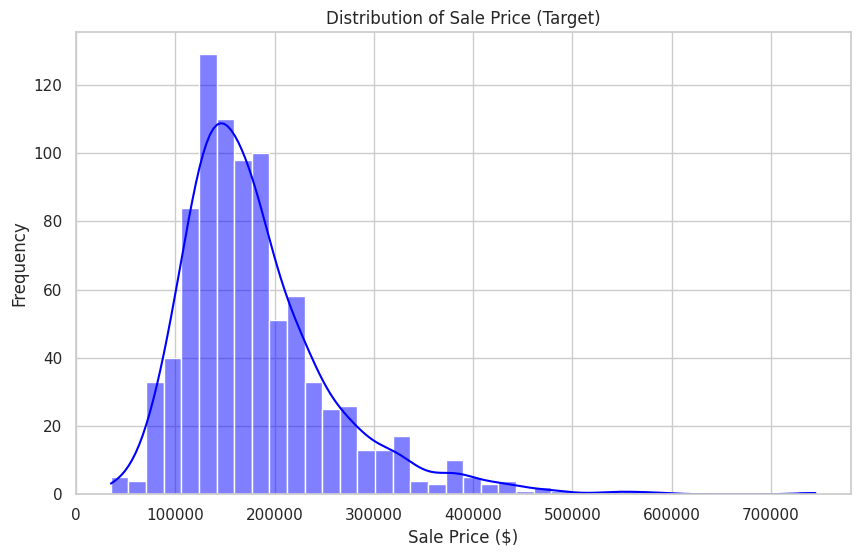

/tmp/ipykernel_382775/3735649131.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.values, y=missing_counts.index, palette='viridis')


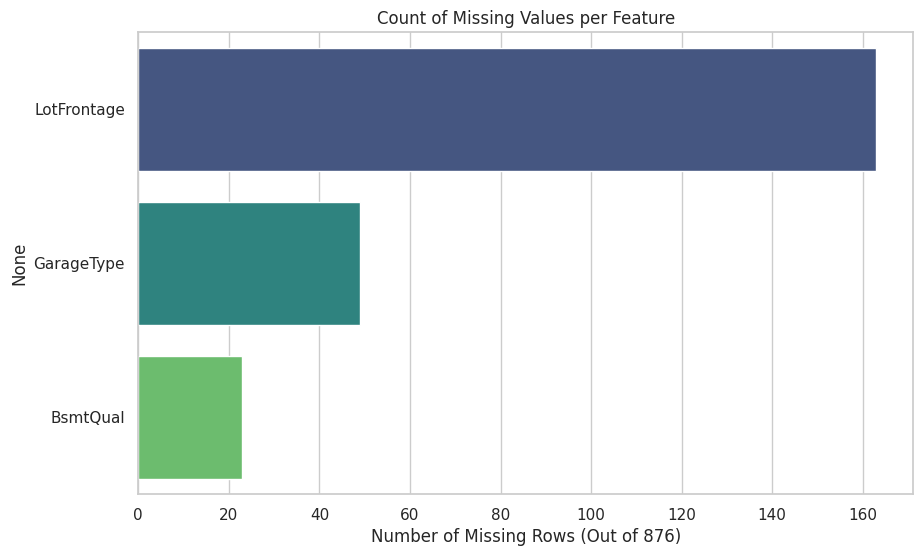

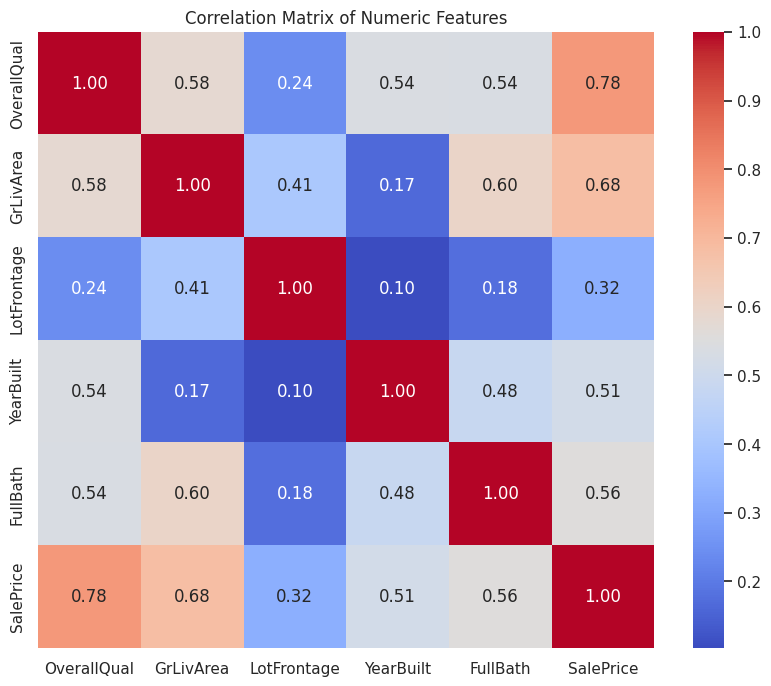

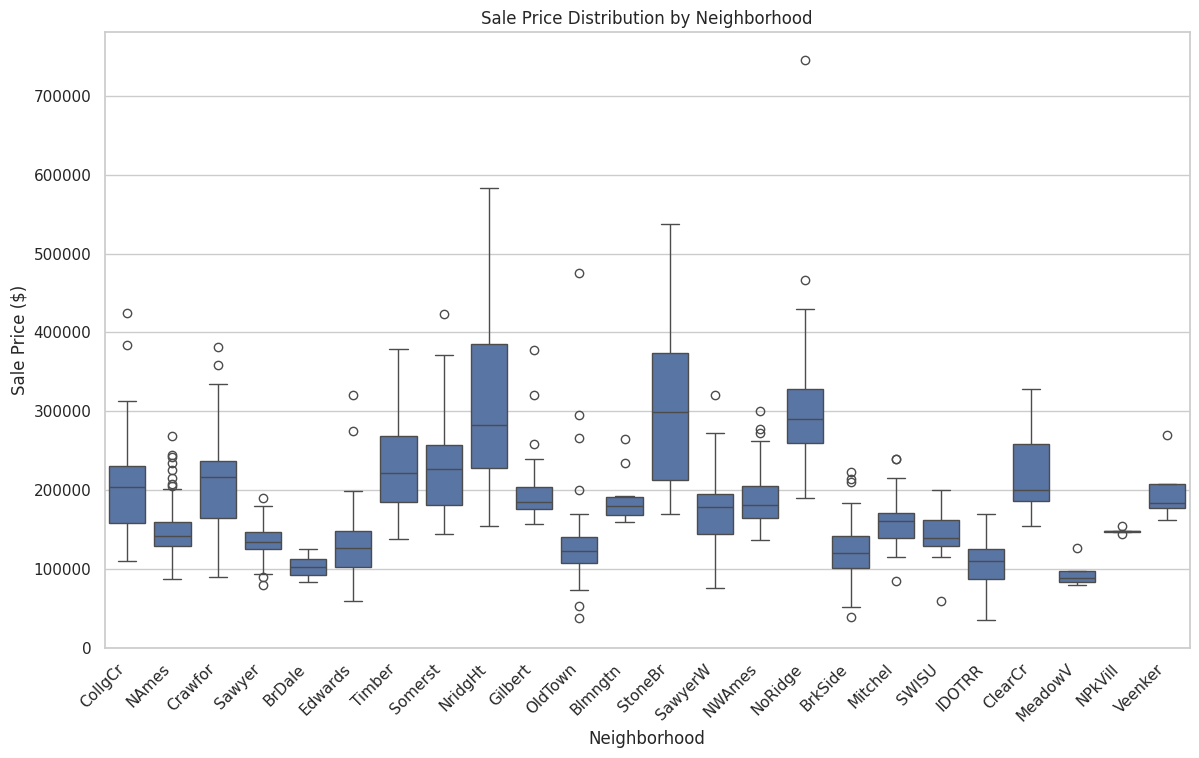

EDA complete. All graphs saved to the /graphs/ directory.


In [27]:
# 1. Load the training data for EDA
df_eda = pd.read_csv(os.path.join(data_dir, 'train_raw.csv'))

# 2. Graph 1: Distribution of SalePrice
plt.figure(figsize=(10, 6))
sns.histplot(df_eda['SalePrice'], kde=True, color='blue', bins=40)
plt.title('Distribution of Sale Price (Target)')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.savefig(os.path.join(graph_dir, '01_target_distribution.png'), bbox_inches='tight')
plt.show()

# 3. Graph 2: Missing Values Count
plt.figure(figsize=(10, 6))
missing_counts = df_eda.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

if not missing_counts.empty:
    sns.barplot(x=missing_counts.values, y=missing_counts.index, palette='viridis')
    plt.title('Count of Missing Values per Feature')
    plt.xlabel('Number of Missing Rows (Out of 876)')
    plt.savefig(os.path.join(graph_dir, '02_missing_values.png'), bbox_inches='tight')
    plt.show()
else:
    print("No missing values found in the training set!")

# 4. Graph 3: Correlation Matrix (Numeric features only)
plt.figure(figsize=(10, 8))
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns
corr_matrix = df_eda[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.savefig(os.path.join(graph_dir, '03_correlation_matrix.png'), bbox_inches='tight')
plt.show()

# 5. Graph 4: Neighborhood vs SalePrice (Categorical impact)
plt.figure(figsize=(14, 8))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df_eda)
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.title('Sale Price Distribution by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Sale Price ($)')
plt.savefig(os.path.join(graph_dir, '04_neighborhood_vs_price.png'), bbox_inches='tight')
plt.show()

print("EDA complete. All graphs saved to the /graphs/ directory.")

### Step 3: Imputation (Handling Missing Values)
**Objective:** Replace missing values in our dataset without causing data leakage.

**The Strategy:**
1. **`LotFrontage` (Continuous Numeric):** We will fill missing values with the **median** value. The median is resistant to extreme outliers (like a massive estate skewing the average). 
2. **`GarageType` & `BsmtQual` (Categorical):** In real estate data, a missing "Garage Type" doesn't mean the data was lost; it means the house *doesn't have a garage*. If we filled this with the "most frequent" value, we would accidentally build phantom garages! Instead, we will fill these NaNs with the string `"None"`.

**The Golden Rule of Imputation:**
We must `fit` our imputer **only on the training data** to learn the median. Then, we use that learned median to `transform` (fill) the training, validation, and test sets.

In [28]:
from sklearn.impute import SimpleImputer

# To be completely safe against out-of-order execution, let's reload our raw splits
df_train = pd.read_csv(os.path.join(data_dir, 'train_raw.csv'))
df_val = pd.read_csv(os.path.join(data_dir, 'val_raw.csv'))
df_test = pd.read_csv(os.path.join(data_dir, 'test_raw.csv'))

print("--- Starting Imputation ---")

# 1. Impute Numerical Features (LotFrontage)
# Initialize the imputer to use the median
num_imputer = SimpleImputer(strategy='median')

# FIT ONLY ON TRAIN to learn the median
num_imputer.fit(df_train[['LotFrontage']])

# Transform all three datasets using the training median
df_train[['LotFrontage']] = num_imputer.transform(df_train[['LotFrontage']])
df_val[['LotFrontage']] = num_imputer.transform(df_val[['LotFrontage']])
df_test[['LotFrontage']] = num_imputer.transform(df_test[['LotFrontage']])

# 2. Impute Categorical Features (GarageType, BsmtQual)
# Initialize the imputer to fill with the word 'None'
cat_imputer = SimpleImputer(strategy='constant', fill_value='None')
cat_cols = ['GarageType', 'BsmtQual']

# Fit and transform
cat_imputer.fit(df_train[cat_cols])

df_train[cat_cols] = cat_imputer.transform(df_train[cat_cols])
df_val[cat_cols] = cat_imputer.transform(df_val[cat_cols])
df_test[cat_cols] = cat_imputer.transform(df_test[cat_cols])

# 3. Verify our cleaning worked
print("\nMissing values remaining in Train set:")
missing_train = df_train.isnull().sum()
print(missing_train[missing_train > 0])

print("\nMissing values remaining in Validation set:")
missing_val = df_val.isnull().sum()
print(missing_val[missing_val > 0])

--- Starting Imputation ---

Missing values remaining in Train set:
Series([], dtype: int64)

Missing values remaining in Validation set:
Series([], dtype: int64)


### Step 4: Ordinal Encoding (Hierarchical Categorical Data)
**Objective:** Convert categorical text columns that have a specific, logical hierarchy into numeric values.

**The Strategy:**
In our 10 features, `ExterQual` (Exterior Quality) and `BsmtQual` (Basement Quality) are ordinal. The text values represent a clear ranking: "Excellent" is mathematically better than "Good", which is better than "Poor". 

If we used One-Hot Encoding here, the model would lose this hierarchical relationship. Instead, we use `OrdinalEncoder` and explicitly tell it the exact order of the categories (e.g., Poor = 0, Fair = 1, Typical = 2, Good = 3, Excellent = 4). Notice that for `BsmtQual`, we put `"None"` at the absolute bottom of the hierarchy (None = 0).

In [29]:
from sklearn.preprocessing import OrdinalEncoder

print("--- Starting Ordinal Encoding ---")

# 1. Define the exact hierarchical order for our ordinal columns
# Note: Ames Housing uses Ex, Gd, TA, Fa, Po. 
# We explicitly map the hierarchy from worst to best.
exter_cats = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
bsmt_cats = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'] # 'None' is the string we imputed earlier!

ordinal_cols = ['ExterQual', 'BsmtQual']

# 2. Initialize the OrdinalEncoder
# handle_unknown='use_encoded_value' is a safety net. If a future user inputs 
# a typo like "Great" instead of "Gd", it won't crash the pipeline; it assigns it -1.
ordinal_encoder = OrdinalEncoder(
    categories=[exter_cats, bsmt_cats], 
    handle_unknown='use_encoded_value', 
    unknown_value=-1
)

# 3. Fit ONLY on the training data to establish the mapping
ordinal_encoder.fit(df_train[ordinal_cols])

# 4. Transform all three datasets
df_train[ordinal_cols] = ordinal_encoder.transform(df_train[ordinal_cols])
df_val[ordinal_cols] = ordinal_encoder.transform(df_val[ordinal_cols])
df_test[ordinal_cols] = ordinal_encoder.transform(df_test[ordinal_cols])

print("Ordinal Encoding successful!")
print("\nSample of transformed data (Notice they are now float numbers):")
print(df_train[ordinal_cols].head())

--- Starting Ordinal Encoding ---
Ordinal Encoding successful!

Sample of transformed data (Notice they are now float numbers):
   ExterQual  BsmtQual
0        3.0       4.0
1        2.0       3.0
2        2.0       3.0
3        2.0       4.0
4        2.0       4.0


### Step 5: Nominal Encoding (One-Hot Encoding)
**Objective:** Convert categorical text columns that have **no logical ranking** into binary numeric columns (0s and 1s).

**The Strategy:**
Features like `Neighborhood`, `HouseStyle`, and `GarageType` are nominal. A "Detached" garage isn't mathematically "greater than" an "Attached" garage; they are just different. If we used `OrdinalEncoder` here, the model would falsely learn that a neighborhood assigned the number 15 is "5 times better" than a neighborhood assigned the number 3.

Instead, we use `OneHotEncoder`. This creates a brand new column for every single category. For example, `GarageType` becomes multiple columns: `GarageType_Attchd`, `GarageType_Detchd`, `GarageType_None`, etc. If a house has an attached garage, it gets a `1` in the `GarageType_Attchd` column and a `0` in the others.

In [30]:
from sklearn.preprocessing import OneHotEncoder

print("--- Starting Nominal (One-Hot) Encoding ---")

# 1. Define our nominal columns
nominal_cols = ['Neighborhood', 'HouseStyle', 'GarageType']

# 2. Initialize OneHotEncoder
# sparse_output=False ensures we get a normal, readable dataframe back, not a compressed matrix.
# handle_unknown='ignore' is crucial for our API: if a user types a neighborhood 
# that wasn't in our training data, it just puts 0s in all neighborhood columns instead of crashing.
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 3. Fit ONLY on the training data
ohe.fit(df_train[nominal_cols])

# 4. Create a function to apply the transformation and stitch it back
def apply_ohe(df, encoder, cols):
    # Transform the text columns into a grid of 0s and 1s
    encoded_array = encoder.transform(df[cols])
    
    # Get the new column names (e.g., 'Neighborhood_CollgCr', 'GarageType_Attchd')
    new_col_names = encoder.get_feature_names_out(cols)
    
    # Convert the array into a DataFrame
    encoded_df = pd.DataFrame(encoded_array, columns=new_col_names, index=df.index)
    
    # Drop the original text columns and attach the new binary columns
    df_dropped = df.drop(columns=cols)
    df_final = pd.concat([df_dropped, encoded_df], axis=1)
    
    return df_final

# 5. Apply the function to all three splits
df_train = apply_ohe(df_train, ohe, nominal_cols)
df_val   = apply_ohe(df_val, ohe, nominal_cols)
df_test  = apply_ohe(df_test, ohe, nominal_cols)

print("Nominal Encoding successful!")
print(f"Old training shape: (876, 11)")
print(f"New training shape: {df_train.shape}")
print("\nSample of new columns:")
print(df_train[[col for col in df_train.columns if 'GarageType' in col]].head())

--- Starting Nominal (One-Hot) Encoding ---
Nominal Encoding successful!
Old training shape: (876, 11)
New training shape: (876, 47)

Sample of new columns:
   GarageType_2Types  GarageType_Attchd  GarageType_Basment  \
0                0.0                1.0                 0.0   
1                0.0                1.0                 0.0   
2                0.0                0.0                 0.0   
3                0.0                1.0                 0.0   
4                0.0                1.0                 0.0   

   GarageType_BuiltIn  GarageType_CarPort  GarageType_Detchd  GarageType_None  
0                 0.0                 0.0                0.0              0.0  
1                 0.0                 0.0                0.0              0.0  
2                 0.0                 0.0                1.0              0.0  
3                 0.0                 0.0                0.0              0.0  
4                 0.0                 0.0                0.0    

### Step 6: Feature Scaling & Saving the Final Data
**Objective:** Standardize our numerical features so they share the same scale, and save the ML-ready datasets.

**The Strategy:**
Machine Learning models look at the raw magnitude of numbers. A `GrLivArea` of 2,000 square feet looks mathematically "bigger" and more important than a `FullBath` count of 2, even though the number of bathrooms is a massive factor in house pricing. 

To fix this, we use `StandardScaler`. This transforms our continuous and ordinal numbers so they all have a mean of 0 and a standard deviation of 1. 
* *Note 1:* We **do not** scale our target variable (`SalePrice`) because we want our model to predict real dollar amounts.
* *Note 2:* We **do not** scale our One-Hot Encoded columns because they are already perfectly scaled as binary 0s and 1s.

In [31]:
from sklearn.preprocessing import StandardScaler

print("--- Starting Feature Scaling ---")

# 1. Define the continuous and ordinal columns that need scaling
cols_to_scale = [
    'GrLivArea', 'LotFrontage', 'YearBuilt', 'FullBath', 
    'OverallQual', 'ExterQual', 'BsmtQual'
]

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. FIT ONLY ON TRAIN to learn the mean and standard deviation
scaler.fit(df_train[cols_to_scale])

# 4. Transform all three datasets
df_train[cols_to_scale] = scaler.transform(df_train[cols_to_scale])
df_val[cols_to_scale] = scaler.transform(df_val[cols_to_scale])
df_test[cols_to_scale] = scaler.transform(df_test[cols_to_scale])

print("Scaling successful!")
print("\nSample of scaled columns (Notice the values are now centered around 0):")
print(df_train[['GrLivArea', 'YearBuilt', 'OverallQual']].head())

# 5. Save the final, perfectly clean datasets to the data directory!
train_path = os.path.join(data_dir, 'train_clean.csv')
val_path = os.path.join(data_dir, 'val_clean.csv')
test_path = os.path.join(data_dir, 'test_clean.csv')

df_train.to_csv(train_path, index=False)
df_val.to_csv(val_path, index=False)
df_test.to_csv(test_path, index=False)

print(f"\n--- SUCCESS ---")
print(f"Cleaned datasets saved to {data_dir}:")
print("- train_clean.csv")
print("- val_clean.csv")
print("- test_clean.csv")

--- Starting Feature Scaling ---
Scaling successful!

Sample of scaled columns (Notice the values are now centered around 0):
   GrLivArea  YearBuilt  OverallQual
0   0.256152   1.026235     2.093671
1  -0.822326  -0.043133    -0.804876
2   0.241069  -1.177311    -0.080239
3  -0.056833  -1.274526     0.644397
4  -0.877004  -0.658830    -1.529513

--- SUCCESS ---
Cleaned datasets saved to /home/bmislol/VSCode/ai-real-estate-agent/data:
- train_clean.csv
- val_clean.csv
- test_clean.csv
